# Clasificación Supervisada de Tickets de Requerimientos

Entrena un clasificador supervisado usando como etiquetas la columna `clasificacion` generada
por el clustering del notebook `EDA_Categorizacion_Requerimientos.ipynb`.

**Dataset:** `tickets_completos_clasificados.csv`  
**Columna objetivo:** `clasificacion`  
**Texto de entrada:** `short_description` + `description`  
**Pipeline de limpieza:** basado en `EDA_Categorizacion_Requerimientos` (spaCy + boilerplate removal + stopwords custom)  
**Modelos:** KNN (cosine), Random Forest, Logistic Regression  
**Split:** 70 % train / 15 % val / 15 % test

## 1. Librerías

In [170]:
import os
import re
import unicodedata
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import spacy
import nltk
from nltk.corpus import stopwords
from tqdm.auto import tqdm

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
)
from scipy.sparse import vstack
from imblearn.over_sampling import RandomOverSampler
import joblib

warnings.filterwarnings('ignore')
tqdm.pandas()
nltk.download('stopwords', quiet=True)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

## 2. Carga de Datos

In [171]:
ruta_csv = os.path.join(os.path.dirname(os.getcwd()), 'Data', 'tickets_completos_clasificados_BASE_SUPERVISADO_FINAL_FINAL.csv')
print('Directorio actual:', os.getcwd())
print('Ruta CSV:', ruta_csv)

try:
    df = pd.read_csv(ruta_csv, encoding='utf-8-sig', sep=',')
except UnicodeDecodeError:
    df = pd.read_csv(ruta_csv, encoding='latin-1', sep=',')

print(f'\nDataset: {df.shape[0]} filas × {df.shape[1]} columnas')
df.head(3)

Directorio actual: c:\ASIGNADOR\Asignador\Analisis
Ruta CSV: c:\ASIGNADOR\Asignador\Data\tickets_completos_clasificados_BASE_SUPERVISADO_FINAL_FINAL.csv

Dataset: 9596 filas × 14 columnas


,number,state,ref_sc_req_item.requested_for,requested_for.vip,requested_for.email,requested_for.title,requested_for.company,assigned_to,assignment_group,short_description,cat_item.sc_catalogs,description,fecha_asignacion,clasificacion
0,RITM0716416,Cerrado,ANGELA MERCEDES OBANDO BERNAL,falso,amobando@pichincha.com,EJECUTIVO BACK Y SERVICIOS,Banco Pichincha C.A.,KONERI DAMODARAM,TEC_TCS_BANCS,Requerimientos de información relacionados a Bancs y BancsLink,TI,"Estimados su gentil ayuda con el cambio de estado chequera CTA CTE: 3168826004 COOPERATIVA DE TRANSPORTE DE PASAJEROS EN TAXIS POPULAR N. 7 RANGO 4611-4910 de CANCELADO A DESTRUIDO , CHEQUERA D...",2025-02-16,chequeras_gestion_rangos
1,RITM0620071,Cerrado,JHOSUE DAVID BRITO ASTUDILLO,falso,jbritoas@pichincha.com,SOPORTE ADMINISTRATIVO,Banco Pichincha C.A.,MARCELA YADIRA ZUNIGA UBILLUZ,TEC_TCS_BANCS,Requerimientos de información relacionados a Bancs y BancsLink,TI,¿Cómo se genera la información del archivo de contingencia DET_CHQUES_CAMARA_*? Esta información se solicita en planes de contingencia y nos indican que los datos se extraen directamente de Bancs.,2026-02-06,debito_automatico_pagos
2,RITM0754745,Cerrado,XIOMARA ELIZABETH CEVALLOS TENORIO,falso,xecevall@pichincha.com,EJECUTIVO COMERCIAL RELACIONAL,Banco Pichincha C.A.,LEONELA JACKELINE DELGADO MENDIETA,TEC_TCS_BANCS,Requerimientos de información relacionados a Bancs y BancsLink,TI,¿Buenos días por favor su ayuda con revisión a que corresponde estos valores? Cliente no registra cheques protestados en banck lisnks Atenta a sus comentarios.,2025-12-06,cheques_activos_devolucion


In [172]:
print('Tipos de datos:')
print(df.dtypes)
print('\nValores nulos por columna:')
print(df.isnull().sum().sort_values(ascending=False))

Tipos de datos:
number                           str
state                            str
ref_sc_req_item.requested_for    str
requested_for.vip                str
requested_for.email              str
requested_for.title              str
requested_for.company            str
assigned_to                      str
assignment_group                 str
short_description                str
cat_item.sc_catalogs             str
description                      str
fecha_asignacion                 str
clasificacion                    str
dtype: object

Valores nulos por columna:
assigned_to                      76
requested_for.email               2
requested_for.company             2
description                       2
requested_for.title               2
ref_sc_req_item.requested_for     1
cat_item.sc_catalogs              1
requested_for.vip                 0
number                            0
state                             0
short_description                 0
assignment_group            

## 3. Análisis Exploratorio (EDA)

### 3.1 Distribución de clases

In [173]:
conteo_clases = df['clasificacion'].value_counts()
print(f'Total de clases únicas: {conteo_clases.nunique()}')
print(f'Total de tickets: {len(df)}')
print('\nDistribución:')
print(conteo_clases.to_string())

Total de clases únicas: 32
Total de tickets: 9596

Distribución:
clasificacion
formas_numeradas                      730
cheques_activos_devolucion            703
chequeras_gestion_rangos              612
gestion_cuentas_activacion            610
soporte_transacciones_produccion      522
glif_journal_contabilidad_test        496
soporte_transacciones_test            469
iniciativas                           456
opciones_menu_bancslinks              435
incidencias_cuentas_modulos           388
banca_empresas_movimientos            323
certificados_deposito_destruccion     317
operaciones_credito_amortizacion      273
cheques_emergencia_certificados       249
revision                              234
facturacion_comisiones_bancarias      226
estados_cuenta                        218
reportes_bancslink_online             210
inversiones_intereses_mora            201
comprobantes_pignoracion_impresion    200
mt940_swift_extractos                 196
cuentas_ahorro_reactivacion           1

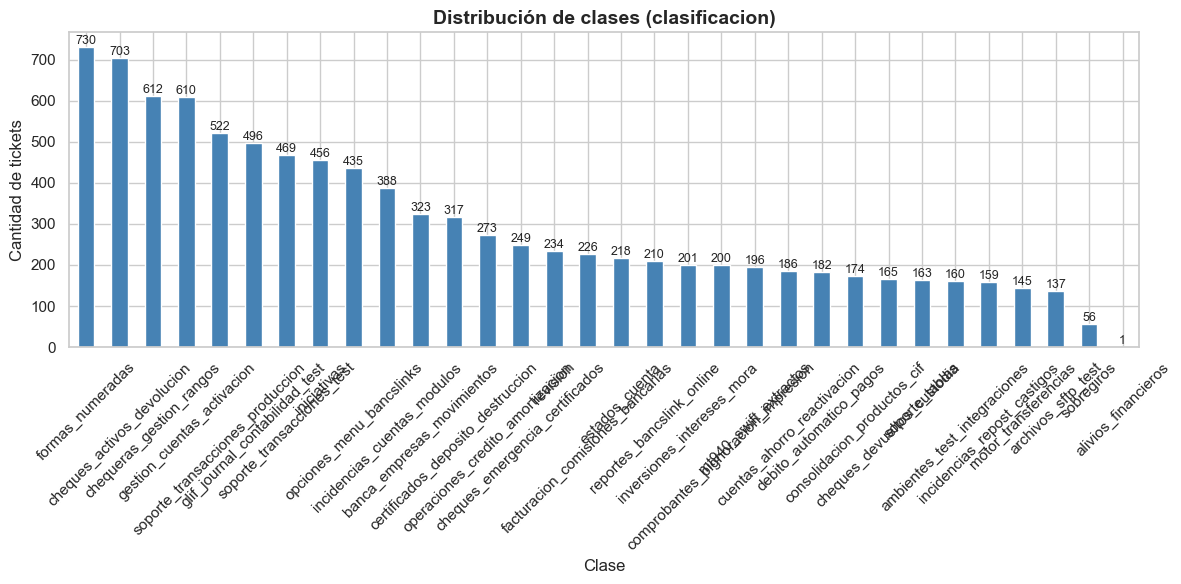

In [174]:
fig, ax = plt.subplots(figsize=(12, 6))
conteo_clases.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Distribución de clases (clasificacion)', fontsize=14, fontweight='bold')
ax.set_xlabel('Clase')
ax.set_ylabel('Cantidad de tickets')
ax.tick_params(axis='x', rotation=45)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

### 3.2 Variables categóricas vs clasificación

In [175]:
# Analizar variables categóricas con pocas categorías únicas
cat_cols = ['state', 'assignment_group', 'cat_item.sc_catalogs', 'requested_for.vip']
for col in cat_cols:
    if col in df.columns:
        print(f'\n--- {col} ---')
        print(f'  Valores únicos: {df[col].nunique()}')
        print(df[col].value_counts().head(10).to_string())


--- state ---
  Valores únicos: 5
state
Cerrado               8726
Cancelado              798
En proceso              48
Pendiente               16
Cerrado Incompleto       8

--- assignment_group ---
  Valores únicos: 2
assignment_group
TEC_TCS_BANCS                  9546
TEC_TCS_N1_RYR_APLICACIONES      50

--- cat_item.sc_catalogs ---
  Valores únicos: 3
cat_item.sc_catalogs
TI             9587
Seguridad         7
Operaciones       1

--- requested_for.vip ---
  Valores únicos: 2
requested_for.vip
falso        9441
verdadero     155


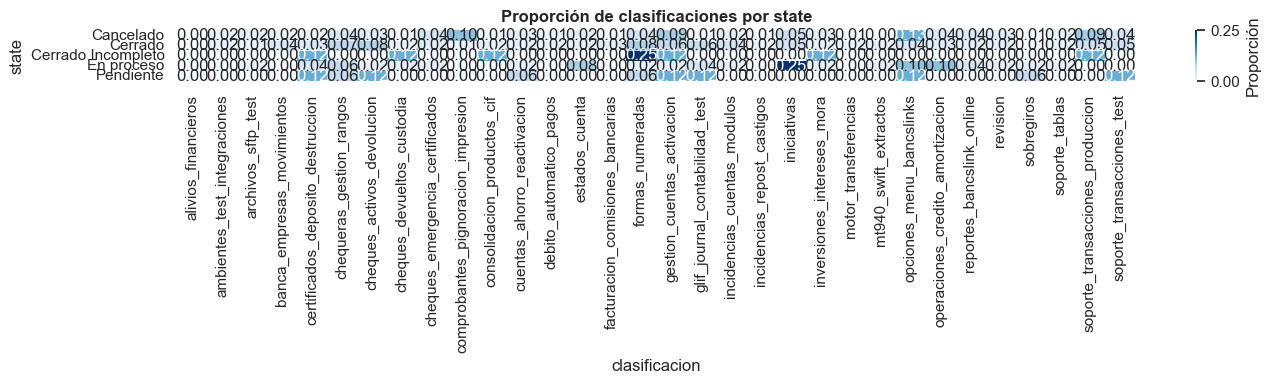

In [176]:
# Heatmap: state vs clasificacion
if 'state' in df.columns:
    tabla = pd.crosstab(df['state'], df['clasificacion'], normalize='index')
    fig, ax = plt.subplots(figsize=(14, max(4, len(tabla) * 0.5)))
    sns.heatmap(tabla, annot=True, fmt='.2f', cmap='Blues', ax=ax, cbar_kws={'label': 'Proporción'})
    ax.set_title('Proporción de clasificaciones por state', fontweight='bold')
    plt.tight_layout()
    plt.show()

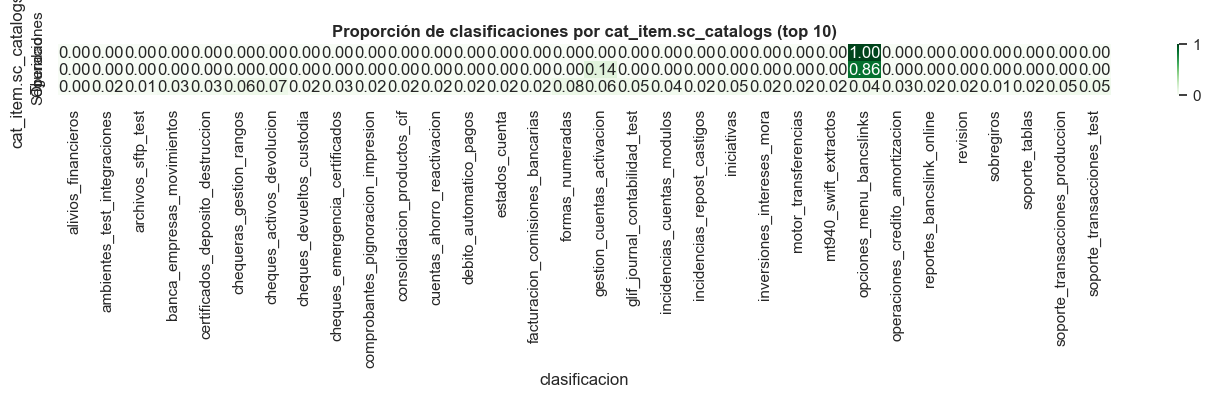

In [177]:
# Heatmap: cat_item.sc_catalogs vs clasificacion
if 'cat_item.sc_catalogs' in df.columns:
    top_cats = df['cat_item.sc_catalogs'].value_counts().head(10).index
    df_top = df[df['cat_item.sc_catalogs'].isin(top_cats)]
    tabla2 = pd.crosstab(df_top['cat_item.sc_catalogs'], df_top['clasificacion'], normalize='index')
    fig, ax = plt.subplots(figsize=(14, max(4, len(tabla2) * 0.5)))
    sns.heatmap(tabla2, annot=True, fmt='.2f', cmap='Greens', ax=ax)
    ax.set_title('Proporción de clasificaciones por cat_item.sc_catalogs (top 10)', fontweight='bold')
    plt.tight_layout()
    plt.show()

### 3.3 Longitud del texto

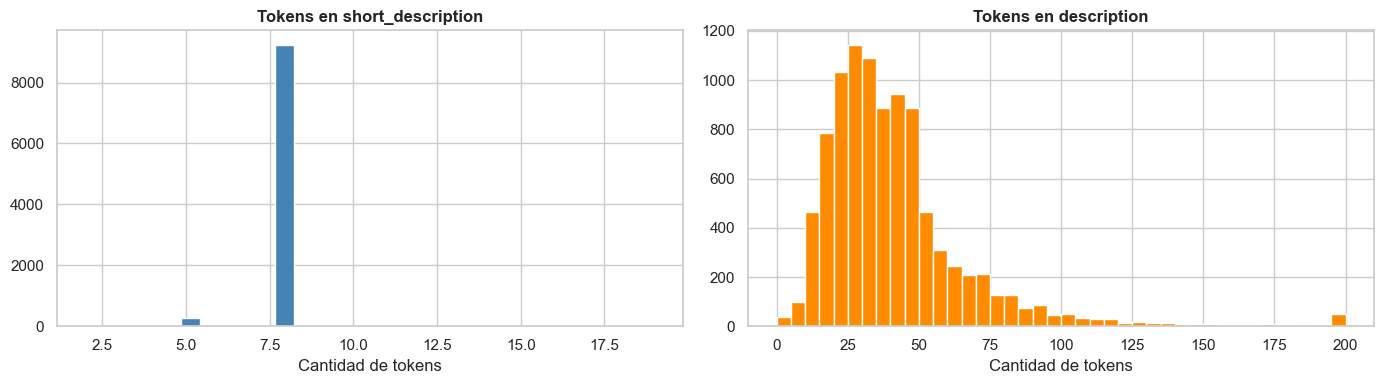

short_description — mediana: 8 tokens, vacíos: 0
description       — mediana: 35 tokens, vacíos: 2


In [178]:
df['len_short'] = df['short_description'].fillna('').apply(lambda x: len(str(x).split()))
df['len_desc']  = df['description'].fillna('').apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df['len_short'].clip(0, 50), bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Tokens en short_description', fontweight='bold')
axes[0].set_xlabel('Cantidad de tokens')
axes[1].hist(df['len_desc'].clip(0, 200), bins=40, color='darkorange', edgecolor='white')
axes[1].set_title('Tokens en description', fontweight='bold')
axes[1].set_xlabel('Cantidad de tokens')
plt.tight_layout()
plt.show()

print(f'short_description — mediana: {df["len_short"].median():.0f} tokens, vacíos: {(df["len_short"]==0).sum()}')
print(f'description       — mediana: {df["len_desc"].median():.0f} tokens, vacíos: {(df["len_desc"]==0).sum()}')

### 3.4 Tickets que mencionan "estado(s) de cuenta"

In [179]:
patron_edo = r'estados?\s+de\s+cuenta[s]?'

mask_edo = df['description'].str.contains(patron_edo, case=False, na=False, regex=True)

df_edo = df[mask_edo][['number', 'clasificacion', 'description']].copy()

print(f'Tickets que mencionan "estado(s) de cuenta": {len(df_edo)}')
print(f'\nDistribución por clase:')
print(df_edo['clasificacion'].value_counts().to_string())

pd.set_option('display.max_colwidth', 200)
df_edo[['number', 'clasificacion', 'description']].reset_index(drop=True)

Tickets que mencionan "estado(s) de cuenta": 261

Distribución por clase:
clasificacion
estados_cuenta    211
iniciativas        50


,number,clasificacion,description
0,RITM0276416,estados_cuenta,URGENTE FAVOR SU AYUDA CON EL CAMBIO DE ESTADO DE CUENTA DE CANCELADO A ACTIVO DE LAS CUENTAS N. 2207576901 N. 2209994499 Y N. 2209994500 DE LA CLIENTE CIFUENTES GUARANGUAY LAURA DANIELA CON CEDUL...
1,RITM0584694,estados_cuenta,"Su gentil ayuda no permite el cambio de estado de cuenta PLAN AHORRO FUTURO RESERVA USD 2200563434 PENDIENTE POR CANCELAR, se requiere activar la cuenta para el retiro de los fondos y cancelar la ..."
2,RITM0584278,estados_cuenta,"Su gentil ayuda no permite el cambio de estado de cuenta PLAN AHORRO FUTURO RESERVA USD 2200563434 PENDIENTE POR CANCELAR, se requiere activar la cuenta para el retiro de los fondos y cancelar la ..."
3,RITM0202992,estados_cuenta,"Su gentil ayuda del cliente ROBLES HERRERA NARCISA DEL ROSARIO CI 1706976204 nunca se ha generado estados de cuenta, tampoco despliega estados de cuenta en Consola Histórica, es posible al menos g..."
4,RITM0854676,estados_cuenta,su gentil ayuda con los estados de cuenta de la cuenta 2100048014 del mes de febrero 2014 y abril 2014 para revisión de información e ingreso de requerimiento
...,...,...,...
256,RITM0532076,iniciativas,**ASIGNADO A SEBASTIÁN C. ** Mejora Estados de Cuenta Proceso Macro: Facturación Electrónica Proceso: Generación reportes de Facturación Electrónica Descripción: Optimizar el proceso de generación...
257,RITM0542374,iniciativas,"**ASIGNADO A KEVIN C. ** Mejora Estados de Cuenta Proceso Macro: Extracción Proceso: Actualización Fechas de corte Descripción: Optimizar el proceso de actualización de fechas de corte, el proceso..."
258,RITM0514955,iniciativas,"**ASIGNADO A KEVIN C. ** Mejora Estados de Cuenta Proceso Macro: Extracción Proceso: Actualización Fechas de corte Descripción: Optimizar el proceso de actualización de fechas de corte, el proceso..."
259,RITM0542378,iniciativas,"**ASIGNADO A BRYAN R. ** Mejora Estados de Cuenta Proceso Macro: Transmisión Proceso: Transmisión archivos al SFTP Descripción: Optimizar el proceso de transmisión de archivos al SFTP, actualmente..."


## 4. Normalización de Etiquetas

In [180]:
def normalizar_clasificacion(texto):
    if pd.isnull(texto):
        return 'sin_clasificar'
    t = str(texto).strip().lower()
    t = unicodedata.normalize('NFKD', t).encode('ascii', 'ignore').decode('utf-8')
    t = re.sub(r'\s+', ' ', t).strip()
    return t if t else 'sin_clasificar'

df['clasificacion'] = df['clasificacion'].apply(normalizar_clasificacion)

print('Distribución de clases tras normalización:')
print(df['clasificacion'].value_counts().to_string())

Distribución de clases tras normalización:
clasificacion
formas_numeradas                      730
cheques_activos_devolucion            703
chequeras_gestion_rangos              612
gestion_cuentas_activacion            610
soporte_transacciones_produccion      522
glif_journal_contabilidad_test        496
soporte_transacciones_test            469
iniciativas                           456
opciones_menu_bancslinks              435
incidencias_cuentas_modulos           388
banca_empresas_movimientos            323
certificados_deposito_destruccion     317
operaciones_credito_amortizacion      273
cheques_emergencia_certificados       249
revision                              234
facturacion_comisiones_bancarias      226
estados_cuenta                        218
reportes_bancslink_online             210
inversiones_intereses_mora            201
comprobantes_pignoracion_impresion    200
mt940_swift_extractos                 196
cuentas_ahorro_reactivacion           186
debito_automatico_p

## 5. Preprocesamiento de Texto

Se utiliza la misma pipeline de limpieza del notebook `EDA_Categorizacion_Requerimientos`:
- Normalización unicode + enmascaramiento de URLs, emails, fechas y números
- Lematización con spaCy (`es_core_news_md`)
- Eliminación de boilerplate (saludos, cortesías, frases genéricas)
- Construcción de texto final priorizando `description` sobre `short_description`

### 5.1 Carga de spaCy y función normalize_text

In [181]:
nlp_es = spacy.load('es_core_news_md', disable=['ner', 'parser', 'senter'])

_PLACEHOLDERS = {'url', 'email', 'fecha', 'num_largo', 'num'}

def normalize_text(texto):
    if pd.isna(texto):
        return ''
    t = str(texto).strip().lower()
    # Normalizar unicode conservando acentos (spaCy los necesita)
    t = unicodedata.normalize('NFKC', t)
    # Enmascarar patrones ruidosos antes de lematizar
    t = re.sub(r'(https?://\S+|www\.\S+)', ' url ', t)
    t = re.sub(r'\b[\w\.-]+@[\w\.-]+\.\w+\b', ' email ', t)
    t = re.sub(r'\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b', ' fecha ', t)
    t = re.sub(r'\b\d{7,}\b', ' num_largo ', t)
    t = re.sub(r'\b\d+\b', ' num ', t)
    # Quitar puntuación conservando letras acentuadas
    t = re.sub(r'[_\-=/\\|()[\]{},;:]+', ' ', t)
    t = re.sub(r'[^\w\s]', ' ', t)
    t = re.sub(r'\s+', ' ', t).strip()
    # Eliminar secuencias de caracteres repetidos (xxxxx, -----, =====)
    t = re.sub(r'(.)\1{3,}', ' ', t)
    t = re.sub(r'\s+', ' ', t).strip()
    # Lematizar con spaCy
    doc = nlp_es(t)
    lemmas = []
    for token in doc:
        if token.is_space:
            continue
        raw = token.lower_.strip()
        if raw in _PLACEHOLDERS:
            lemmas.append(raw)
        else:
            lemma = token.lemma_.lower().strip()
            if lemma:
                lemmas.append(lemma)
    t = ' '.join(lemmas)
    # Quitar acentos → ASCII puro
    t = unicodedata.normalize('NFKD', t).encode('ascii', 'ignore').decode('utf-8', errors='ignore')
    # Solo letras y números
    t = re.sub(r'[^a-z0-9\s]', ' ', t)
    t = re.sub(r'\s+', ' ', t).strip()
    return t

### 5.2 Stopwords custom

In [182]:
def _norm_sw(w):
    t = str(w).lower().strip()
    t = unicodedata.normalize('NFKD', t).encode('ascii', 'ignore').decode('utf-8')
    return t

STOP_ES = list(set(
    _norm_sw(w) for w in (
        stopwords.words('spanish')
        + [
            # Artefactos de normalización
            'num', 'num_largo', 'fecha', 'fechas', 'email', 'url', 'largo',
            # Temporales
            'enero', 'febrero', 'marzo', 'abril', 'mayo', 'junio',
            'julio', 'agosto', 'septiembre', 'octubre', 'noviembre', 'diciembre',
            'dia', 'dias', 'mes', 'meses', 'semana', 'semanas', 'momento',
            # Cortesía y boilerplate
            'favor', 'apoyo', 'ayuda', 'gracias', 'gracia', 'estimado', 'estimada', 'estimados',
            'hola', 'buen', 'bueno', 'buena', 'atencion',
            'cordial', 'amable', 'esperar', 'adjuntar', 'agradecer', 'agradecere',
            'atento', 'comentario', 'colaboracion', 'gentil',
            # Nombres propios y geografía
            'cristian', 'orellana', 'quevedo', 'california', 'parque', 'ecuador',
            'empalme', 'pichincha', 'sur', 'riobamba', 'paseo', 'rubianes', 'patricio',
            'quito', 'regional', 'carlos', 'jorge', 'maria', 'ana', 'juan', 'jose',
            'luis', 'paulin', 'diego', 'rodriguez', 'shopping', 'daule', 'manta',
            'cuenca', 'centro', 'san', 'christian', 'veronica', 'moreno',
            # Terminología bancaria genérica
            'cliente', 'cuenta', 'banco', 'bancs', 'bancslink', 'banclink',
            'tcs', 'sistema', 'aplicativo', 'aplicacion', 'servicio', 'usuario',
            'solicitud', 'requerimiento', 'incidente', 'ticket', 'caso',
            'proceso', 'procesamiento', 'transaccion', 'operacion',
            'informacion', 'datos', 'dato', 'registro', 'archivo',
            'numero', 'numeros', 'valor', 'valores',
            'revision', 'revisiones', 'documento', 'formato',
            'notificacion', 'correo', 'portal', 'modulo',
            # Demostrativos y cuantificadores genéricos
            'dichas', 'dicho', 'dichos', 'mismo', 'misma', 'mismos', 'mismas',
            'siguiente', 'siguientes', 'anteriores', 'correspondiente',
            'algun', 'alguna', 'algunos', 'algunas', 'alguno',
            'segun', 'dos', 'tres', 'ningun', 'ninguna',
            # Sustantivos ultra-genéricos
            'nombre', 'parte', 'generacion', 'obtencion', 'muchas',
            'opcion', 'observacion',
            # Adverbios y expresiones genéricas
            'bien', 'dar', 'ver', 'presenta', 'actualmente', 'prueba',
            'confirmacion', 'perteneciente', 'gerente', 'autorizacion',
            'mall', 'rio', 'telefono', 'detallar', 'contener', 'solo',
            'desear', 'jefe', 'amablemente', 'hacia', 'via',
            'proyecto', 'suficiente', 'mejora', 'adjunta', 'adjunto',
        ]
    )
))

print(f'Total de stopwords: {len(STOP_ES)}')

Total de stopwords: 479


### 5.3 Eliminación de boilerplate

In [183]:
boilerplate_patterns = [
    r'\brequerimientos?\s+de\s+informacion\s+relacionados?\s+a\s+bancs?\s+y\s+bancslinks?\b',
    r'\batencion\s+solicitudes?\s+bancs?\s+y\s+bancslinks?\b',
    r'\bestimad[oa]s?\b',
    r'\bbuen[oa]s?\s+d[ii]as?\b',
    r'\bbuen[oa]s?\s+tardes?\b',
    r'\bbuen[oa]s?\s+noches?\b',
    r'\bbuen\s+d[ii]a\b',
    r'^\s*estimad[oa]s?\b',
    r'^\s*buen[oa]s?\s+d[ii]as\b',
    r'^\s*buen[oa]s?\s+tardes\b',
    r'^\s*buen[oa]s?\s+noches\b',
    r'\bespero\s+se\s+encuentren\s+bien\b',
    r'\bpor\s+favor\b',
    r'\bfavor\b',
    r'\bfavor\s+con\b',
    r'\bsu\s+gentil\s+ayuda\b',
    r'\bsu\s+ayuda\b',
    r'\bsu\s+gentil\s+apoyo\b',
    r'\bsu\s+apoyo\b',
    r'\bgentil\s+apoyo\b',
    r'\bfavor\s+su\s+ayuda\b',
    r'\bpor\s+favor\s+su\s+ayuda\s+con\b',
    r'\bpor\s+favor\s+su\s+apoyo\s+con\b',
    r'\bpor\s+favor\s+apoyar\b',
    r'\bpor\s+favor\s+ayudar\b',
    r'\bsu\s+gentil\s+apoyo\s+con\b',
    r'\bsu\s+ayuda\s+con\b',
    r'\bapoyo\s+con\b',
    r'\bayuda\s+con\b',
    r'\batenta?\s+a\s+sus\s+comentarios\b',
    r'\bquedo\s+atent[oa]\b',
    r'\bde\s+antemano\b',
    r'\bles\s+agradezco\b',
    r'\bagradezco\s+su\s+ayuda\b',
    r'\bcordial(?:es)?\s+saludos\b',
    r'\bsaludos?\s+cordiales?\b',
    r'\bsaludos?\b',
    r'\bgracias\b',
    r'\badjunto\b',
    r'\besperar\s+se\s+encontrar\s+bien\b',
    r'\badjuntar\b',
    r'\bquedar\s+atent[oa]\b',
    r'\bcordial(?:es)?\s+saludo[s]?\b',
    r'\bgracia[s]?\b',
    r'\ble[s]?\s+agradecer\b',
    r'\bagradecer\s+su\s+ayuda\b',
    r'\batento?\s+a\s+su[s]?\s+comentario[s]?\b',
]

boilerplate_regex = re.compile('|'.join(boilerplate_patterns))
prefix_regex = re.compile(r'^(con|con el|con la|con los|con las|para|sobre|del|de la|de los|de las)\s+')

def strip_boilerplate(texto):
    if pd.isna(texto):
        return ''
    t = str(texto)
    for _ in range(6):
        t_new = boilerplate_regex.sub(' ', t)
        t_new = re.sub(r'\s+', ' ', t_new).strip()
        if t_new == t:
            break
        t = t_new
    for _ in range(4):
        t_new = prefix_regex.sub('', t).strip()
        if t_new == t:
            break
        t = t_new
    return re.sub(r'\s+', ' ', t).strip()

print('Funciones de boilerplate definidas.')

Funciones de boilerplate definidas.


### 5.4 Aplicar limpieza

In [184]:
# normalize_text puede tardar varios minutos en datasets grandes
print('Aplicando normalize_text a short_description...')
df['short_norm'] = df['short_description'].progress_apply(normalize_text)

print('Aplicando normalize_text a description...')
df['desc_norm'] = df['description'].progress_apply(normalize_text)

print('Listo.')

Aplicando normalize_text a short_description...


100%|██████████| 9596/9596 [01:50<00:00, 87.02it/s] 


Aplicando normalize_text a description...


100%|██████████| 9596/9596 [02:32<00:00, 62.84it/s] 

Listo.


In [185]:
# Aplicar strip_boilerplate
df['short_core'] = df['short_norm'].apply(strip_boilerplate)
df['desc_core']  = df['desc_norm'].apply(strip_boilerplate)

print('Boilerplate removido.')

Boilerplate removido.


In [186]:
def es_texto_informativo(txt, min_tokens=4):
    if pd.isna(txt):
        return False
    return len(str(txt).strip().split()) >= min_tokens

def construir_texto_final(row):
    d = row['desc_core']  if pd.notna(row['desc_core'])  else ''
    s = row['short_core'] if pd.notna(row['short_core']) else ''
    d_ok = es_texto_informativo(d)
    s_ok = es_texto_informativo(s)
    if d_ok and s_ok:
        return (d + ' ' + s).strip(), 'desc+short'
    if d_ok:
        return d.strip(), 'desc'
    if s_ok:
        return s.strip(), 'short'
    return '', 'none'

tmp = df.apply(construir_texto_final, axis=1)
df['texto_limpio'] = tmp.apply(lambda x: x[0])
df['source_text']  = tmp.apply(lambda x: x[1])

print('Distribución de fuentes de texto:')
print(df['source_text'].value_counts())
print(f'\nTickets sin texto válido: {(df["texto_limpio"] == "").sum()}')

Distribución de fuentes de texto:
source_text
desc          9283
desc+short     311
short            2
Name: count, dtype: int64

Tickets sin texto válido: 0


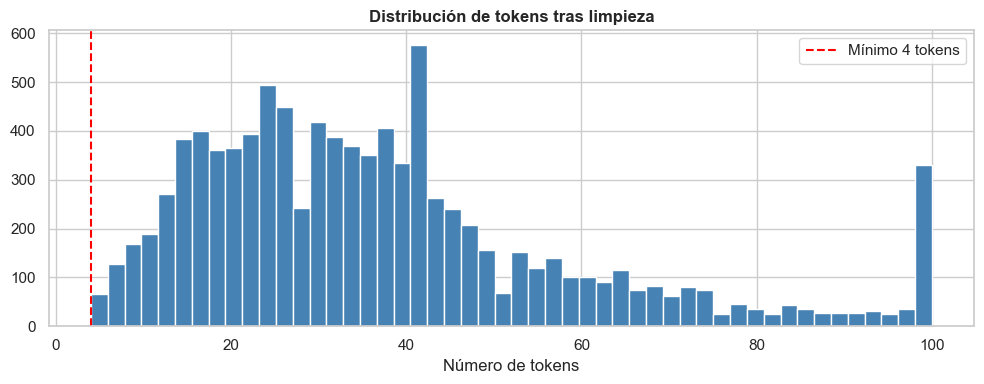

Mediana tokens: 33
Textos con < 4 tokens: 0


In [187]:
df['n_tokens'] = df['texto_limpio'].apply(lambda x: len(str(x).split()))

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df['n_tokens'].clip(0, 100), bins=50, color='steelblue', edgecolor='white')
ax.axvline(4, color='red', linestyle='--', label='Mínimo 4 tokens')
ax.set_title('Distribución de tokens tras limpieza', fontweight='bold')
ax.set_xlabel('Número de tokens')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Mediana tokens: {df["n_tokens"].median():.0f}')
print(f'Textos con < 4 tokens: {(df["n_tokens"] < 4).sum()}')

## 6. Análisis de Duplicados

Se identifican tickets con texto idéntico pero distintas clasificaciones,
y se asigna la clase mayoritaria para resolver la ambigüedad.

In [188]:
resumen_dups = (
    df.groupby('texto_limpio')['clasificacion']
    .agg(n_clases=pd.Series.nunique,
         clasificaciones=lambda x: ', '.join(sorted(x.unique())),
         conteo=len)
    .reset_index()
)

textos_repetidos = resumen_dups[resumen_dups['conteo'] > 1]
textos_ambiguos  = resumen_dups[(resumen_dups['n_clases'] > 1) & (resumen_dups['texto_limpio'] != '')]

print(f'Textos únicos:            {len(resumen_dups)}')
print(f'Textos repetidos:         {len(textos_repetidos)}')
print(f'Textos con ≥ 2 etiquetas: {len(textos_ambiguos)}')

if len(textos_ambiguos) > 0:
    print('\nEjemplos de textos ambiguos:')
    print(textos_ambiguos.head(5).to_string())

Textos únicos:            8098
Textos repetidos:         559
Textos con ≥ 2 etiquetas: 0


In [189]:
# Asignar clase mayoritaria a textos ambiguos
textos_amb_list = textos_ambiguos['texto_limpio'].tolist()

mapa_mayoritario = {}
for texto in textos_amb_list:
    conteo = df[df['texto_limpio'] == texto]['clasificacion'].value_counts()
    mapa_mayoritario[texto] = conteo.idxmax()

if mapa_mayoritario:
    mask = df['texto_limpio'].isin(textos_amb_list)
    df.loc[mask, 'clasificacion'] = df.loc[mask, 'texto_limpio'].map(mapa_mayoritario)
    print(f'Tickets corregidos por clase mayoritaria: {mask.sum()}')

# Deduplicar (mantener primera ocurrencia)
n_antes = len(df)
df = df[df['texto_limpio'] != ''].drop_duplicates(subset='texto_limpio', keep='first').reset_index(drop=True)
print(f'Filas antes de deduplicar: {n_antes}')
print(f'Filas después:             {len(df)}')
print(f'Eliminadas:                {n_antes - len(df)}')

Filas antes de deduplicar: 9596
Filas después:             8098
Eliminadas:                1498


## 7. División Train / Val / Test

Split estratificado **70 % train / 15 % val / 15 % test**.  
Las clases con un solo ejemplo van directamente a train para no romper la estratificación.

In [190]:
X_all = df['texto_limpio'].values
y_all = df['clasificacion'].values

# Clases con solo 1 ejemplo → van directo a train
conteo_y = pd.Series(y_all).value_counts()
clases_1ej = conteo_y[conteo_y < 2].index.tolist()

if clases_1ej:
    print(f'Clases con 1 solo ejemplo (→ train directo): {clases_1ej}')
    mask_1ej = pd.Series(y_all).isin(clases_1ej).values
    X_1ej, y_1ej = X_all[mask_1ej], y_all[mask_1ej]
    X_rest, y_rest = X_all[~mask_1ej], y_all[~mask_1ej]
else:
    X_1ej = y_1ej = np.array([])
    X_rest, y_rest = X_all, y_all

# 1er split: separar test (15 %)
X_tv, X_test, y_tv, y_test = train_test_split(
    X_rest, y_rest, test_size=0.15, random_state=42, stratify=y_rest
)

# 2do split: separar val del train+val (≈ 15/(70+15) = 17.6 %)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.176, random_state=42, stratify=y_tv
)

# Agregar ejemplos de clases únicas a train
if len(X_1ej) > 0:
    X_train = np.concatenate([X_train, X_1ej])
    y_train = np.concatenate([y_train, y_1ej])

print(f'Train: {len(X_train)} ({len(X_train)/len(X_all):.1%})')
print(f'Val:   {len(X_val)} ({len(X_val)/len(X_all):.1%})')
print(f'Test:  {len(X_test)} ({len(X_test)/len(X_all):.1%})')

Clases con 1 solo ejemplo (→ train directo): ['alivios_financieros']
Train: 5671 (70.0%)
Val:   1212 (15.0%)
Test:  1215 (15.0%)


## 8. Vectorización TF-IDF

El vectorizer se **entrena solo con el train set** para evitar data leakage.

In [191]:
vectorizer = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.80,
    max_features=10_000,
    sublinear_tf=True,
    strip_accents='unicode',
    stop_words=STOP_ES,
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf   = vectorizer.transform(X_val)
X_test_tfidf  = vectorizer.transform(X_test)

print(f'Vocabulario TF-IDF: {len(vectorizer.get_feature_names_out())} términos')
print(f'Matriz train:  {X_train_tfidf.shape}')
print(f'Matriz val:    {X_val_tfidf.shape}')
print(f'Matriz test:   {X_test_tfidf.shape}')

Vocabulario TF-IDF: 10000 términos
Matriz train:  (5671, 10000)
Matriz val:    (1212, 10000)
Matriz test:   (1215, 10000)


## 9. Balanceo de Clases (RandomOverSampler)

Se usa `RandomOverSampler` en lugar de SMOTE: duplica tickets reales sin generar
vectores TF-IDF artificiales sin sentido lingüístico.  
Se aplica **solo sobre el train set**.

In [192]:
ros = RandomOverSampler(random_state=42)
X_train_bal, y_train_bal = ros.fit_resample(X_train_tfidf, y_train)

print(f'Train antes del balanceo:  {X_train_tfidf.shape[0]} muestras')
print(f'Train después del balanceo: {X_train_bal.shape[0]} muestras')
print(f'\nDistribución tras ROS (todas las clases igualadas):')
print(Counter(y_train_bal))

Train antes del balanceo:  5671 muestras
Train después del balanceo: 12928 muestras

Distribución tras ROS (todas las clases igualadas):
Counter({'operaciones_credito_amortizacion': 404, 'mt940_swift_extractos': 404, 'revision': 404, 'glif_journal_contabilidad_test': 404, 'formas_numeradas': 404, 'incidencias_cuentas_modulos': 404, 'iniciativas': 404, 'facturacion_comisiones_bancarias': 404, 'consolidacion_productos_cif': 404, 'opciones_menu_bancslinks': 404, 'gestion_cuentas_activacion': 404, 'comprobantes_pignoracion_impresion': 404, 'incidencias_repost_castigos': 404, 'debito_automatico_pagos': 404, 'soporte_transacciones_produccion': 404, 'inversiones_intereses_mora': 404, 'soporte_tablas': 404, 'cheques_emergencia_certificados': 404, 'cheques_activos_devolucion': 404, 'chequeras_gestion_rangos': 404, 'estados_cuenta': 404, 'soporte_transacciones_test': 404, 'certificados_deposito_destruccion': 404, 'banca_empresas_movimientos': 404, 'cheques_devueltos_custodia': 404, 'sobregiros':

## 10. Entrenamiento de Modelos

### 10.1 KNN — búsqueda del k óptimo en validación

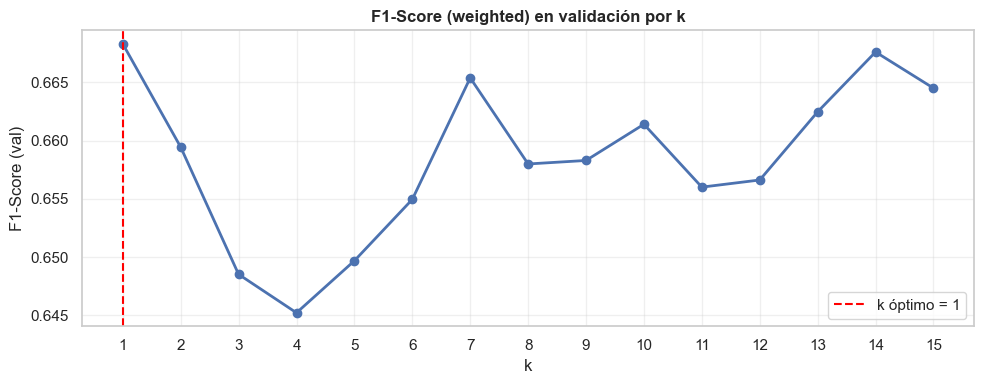

k óptimo: 1  (F1-val: 0.6683)


In [193]:
k_range = range(1, 16)
f1_val_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, metric='cosine')
    knn.fit(X_train_bal, y_train_bal)
    y_pred_val = knn.predict(X_val_tfidf)
    f1_val_scores.append(f1_score(y_val, y_pred_val, average='weighted', zero_division=0))

k_optimo = list(k_range)[int(np.argmax(f1_val_scores))]

plt.figure(figsize=(10, 4))
plt.plot(k_range, f1_val_scores, marker='o', linewidth=2)
plt.axvline(k_optimo, color='red', linestyle='--', label=f'k óptimo = {k_optimo}')
plt.title('F1-Score (weighted) en validación por k', fontweight='bold')
plt.xlabel('k')
plt.ylabel('F1-Score (val)')
plt.xticks(list(k_range))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'k óptimo: {k_optimo}  (F1-val: {max(f1_val_scores):.4f})')

In [194]:
knn_final = KNeighborsClassifier(n_neighbors=k_optimo, metric='cosine')
knn_final.fit(X_train_bal, y_train_bal)
print(f'KNN entrenado con k={k_optimo}')

KNN entrenado con k=1


### 10.2 Random Forest

In [195]:
rf_model = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42, n_jobs=-1)
rf_model.fit(X_train_bal, y_train_bal)
print('Random Forest entrenado (n_estimators=200)')

Random Forest entrenado (n_estimators=200)


### 10.3 Logistic Regression

In [196]:
lr_model = LogisticRegression(C=1.0, max_iter=3000, random_state=42, solver='lbfgs')
lr_model.fit(X_train_bal, y_train_bal)
print('Logistic Regression entrenada (C=1.0)')

Logistic Regression entrenada (C=1.0)


## 11. Evaluación y Selección del Mejor Modelo

Primero se comparan los modelos en el **conjunto de validación** para seleccionar el mejor.
Luego se hace la evaluación final en el **conjunto de test** (que los modelos nunca vieron).

### 11.1 Comparación en validación

In [197]:
modelos = {
    'KNN':                 knn_final,
    'Random Forest':       rf_model,
    'Logistic Regression': lr_model,
}

resultados_val = []
for nombre, modelo in modelos.items():
    y_pred = modelo.predict(X_val_tfidf)
    resultados_val.append({
        'Modelo':    nombre,
        'Accuracy':  accuracy_score(y_val, y_pred),
        'Precision': precision_score(y_val, y_pred, average='weighted', zero_division=0),
        'Recall':    recall_score(y_val, y_pred, average='weighted', zero_division=0),
        'F1-Score':  f1_score(y_val, y_pred, average='weighted', zero_division=0),
    })

df_val = pd.DataFrame(resultados_val).set_index('Modelo')
print('=== Métricas en validación ===')
print(df_val.round(4).to_string())

mejor = df_val['F1-Score'].idxmax()
print(f'\n► Mejor modelo (F1 val): {mejor}  ({df_val.loc[mejor, "F1-Score"]:.4f})')
mejor_modelo = modelos[mejor]

=== Métricas en validación ===
                     Accuracy  Precision  Recall  F1-Score
Modelo                                                    
KNN                    0.6741     0.6681  0.6741    0.6683
Random Forest          0.8251     0.8241  0.8251    0.8191
Logistic Regression    0.8317     0.8300  0.8317    0.8283

► Mejor modelo (F1 val): Logistic Regression  (0.8283)


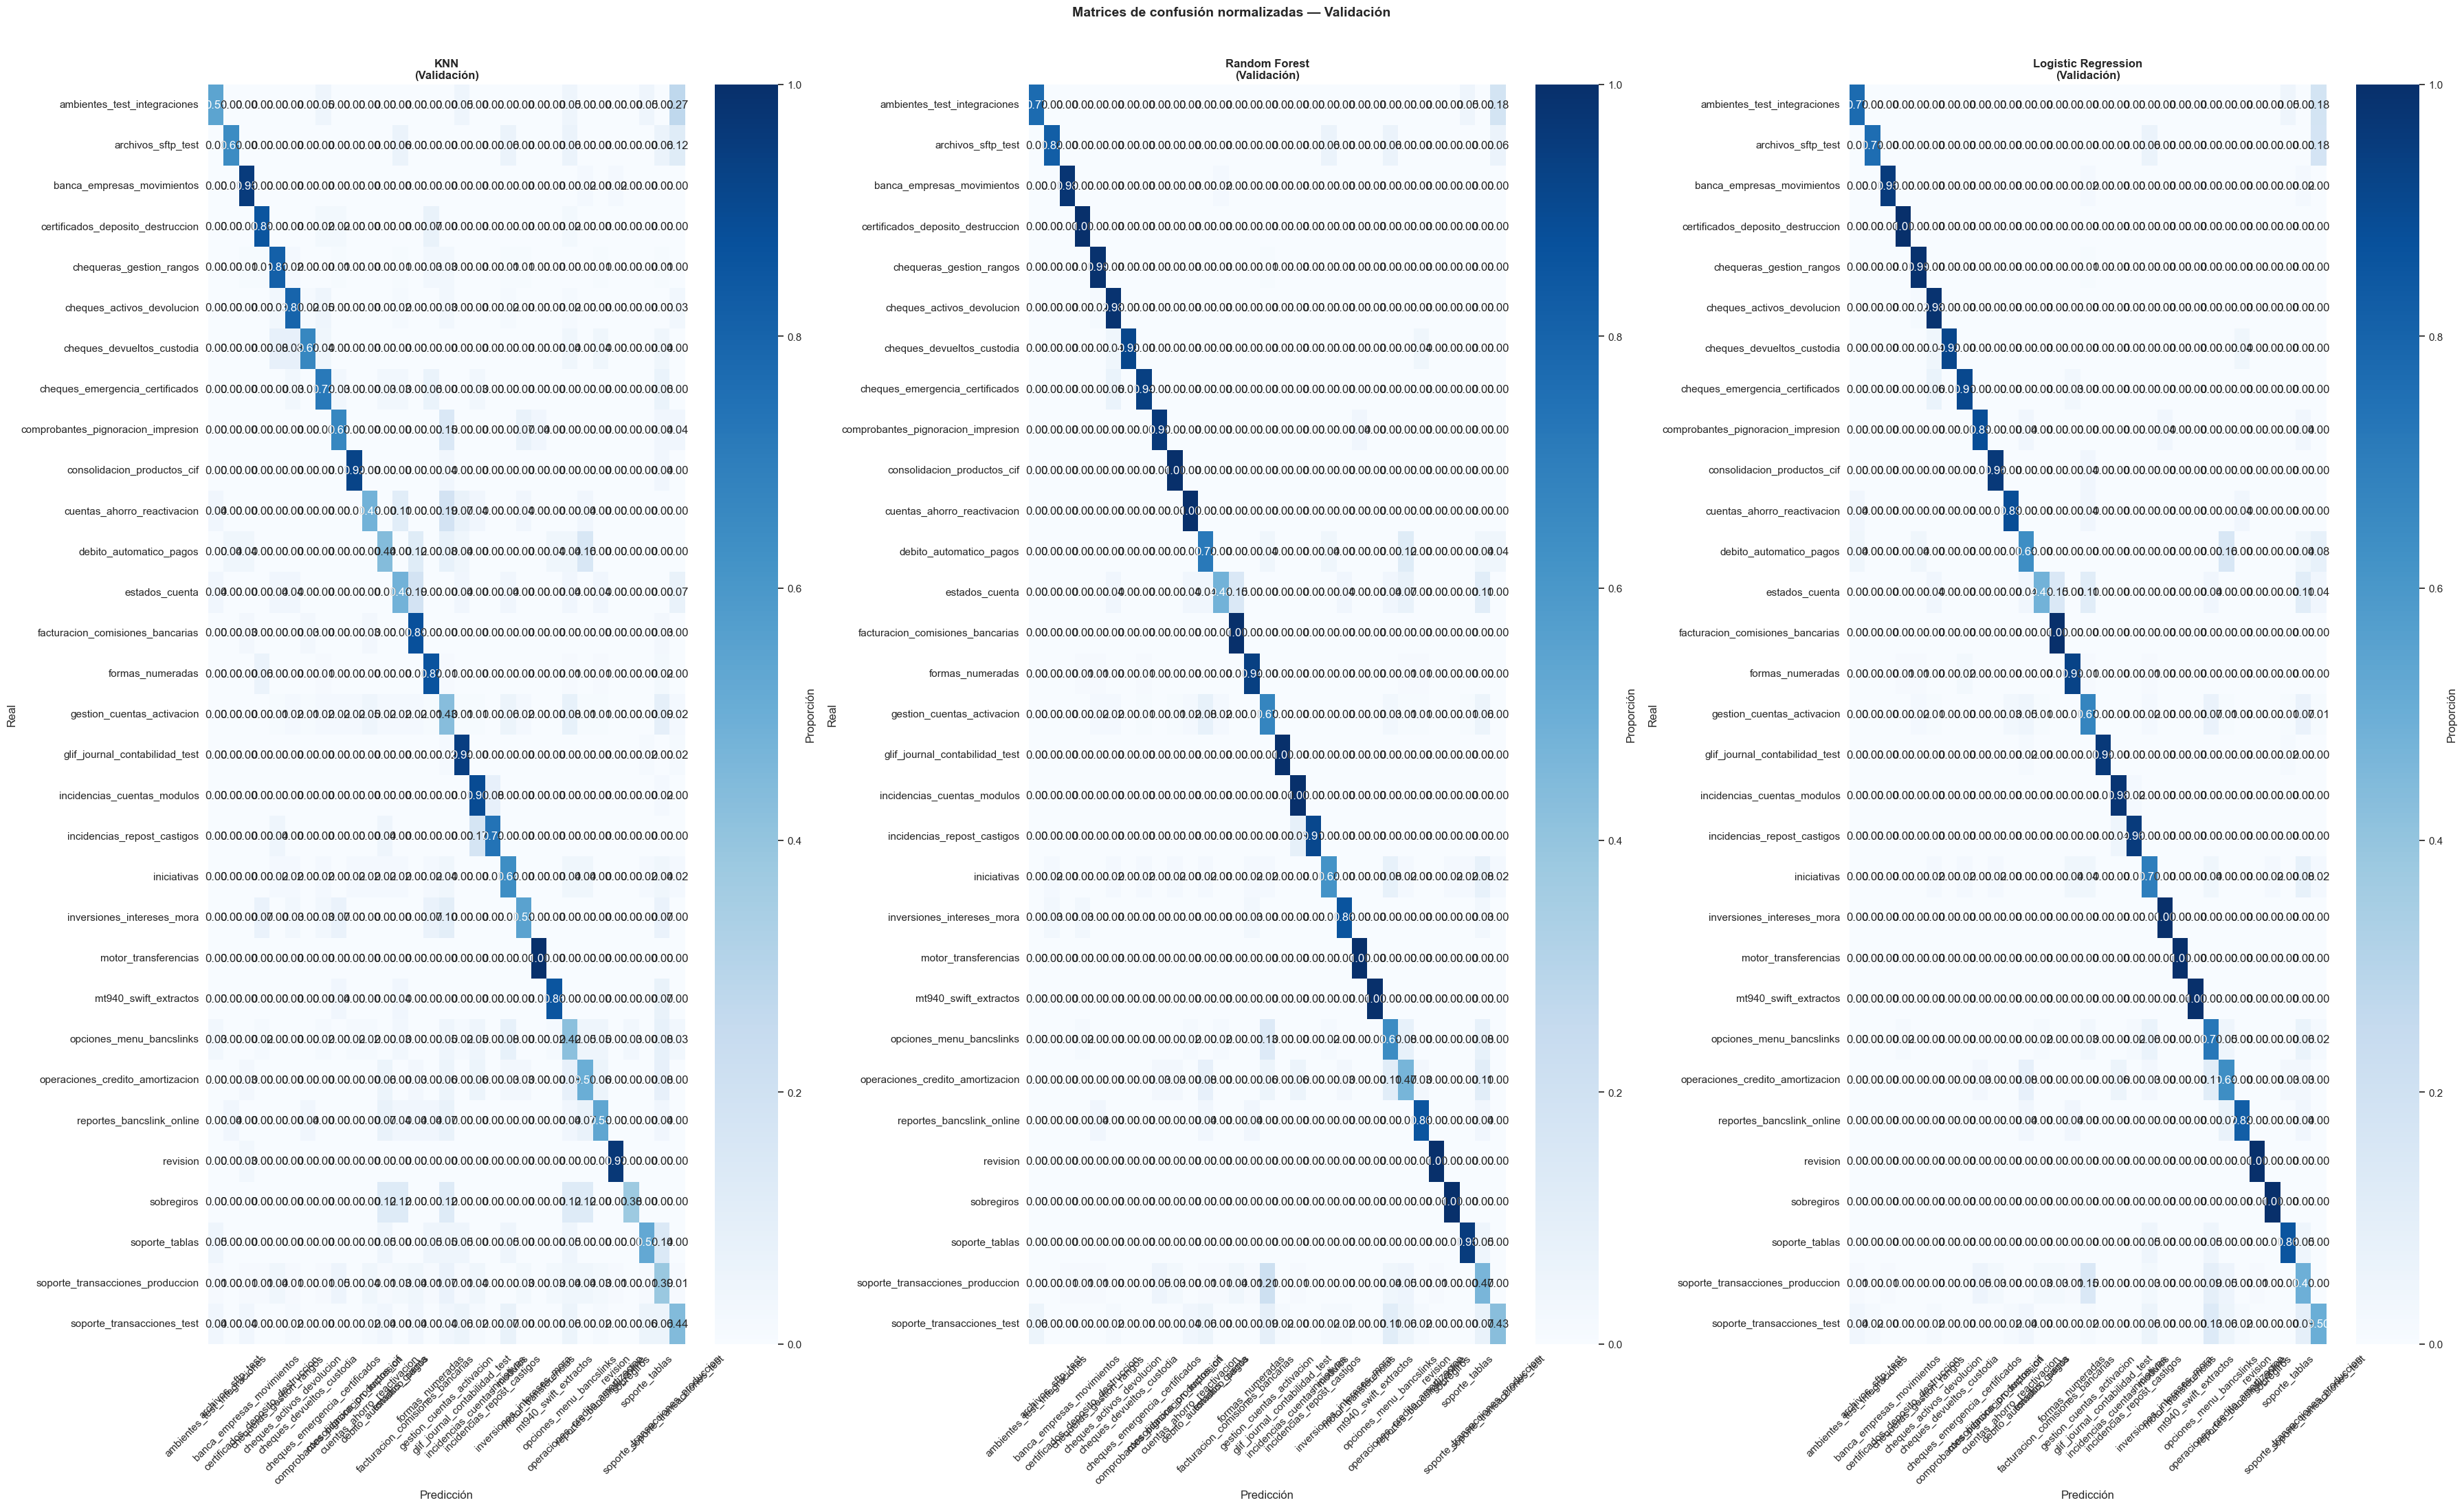

In [198]:
# Matrices de confusión en validación
labels = sorted(set(y_val))
fig, axes = plt.subplots(1, 3, figsize=(36, max(8, len(labels) * 0.7)))

for ax, (nombre, modelo) in zip(axes, modelos.items()):
    y_pred = modelo.predict(X_val_tfidf)
    cm = confusion_matrix(y_val, y_pred, labels=labels)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax,
                cbar_kws={'label': 'Proporción'})
    ax.set_title(f'{nombre}\n(Validación)', fontweight='bold')
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Matrices de confusión normalizadas — Validación', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 11.2 Evaluación final en test

In [199]:
y_pred_test = mejor_modelo.predict(X_test_tfidf)

print(f'=== Evaluación final en TEST SET — {mejor} ===')
print(f'Accuracy:              {accuracy_score(y_test, y_pred_test):.4f}')
print(f'Precision (weighted):  {precision_score(y_test, y_pred_test, average="weighted", zero_division=0):.4f}')
print(f'Recall (weighted):     {recall_score(y_test, y_pred_test, average="weighted", zero_division=0):.4f}')
print(f'F1-Score (weighted):   {f1_score(y_test, y_pred_test, average="weighted", zero_division=0):.4f}')
print()
print(classification_report(y_test, y_pred_test, zero_division=0))

=== Evaluación final en TEST SET — Logistic Regression ===
Accuracy:              0.8288
Precision (weighted):  0.8252
Recall (weighted):     0.8288
F1-Score (weighted):   0.8251

                                    precision    recall  f1-score   support

               alivios_financieros       0.00      0.00      0.00         0
      ambientes_test_integraciones       0.67      0.64      0.65        22
                archivos_sftp_test       0.67      0.59      0.62        17
        banca_empresas_movimientos       0.98      0.98      0.98        43
 certificados_deposito_destruccion       0.98      0.98      0.98        42
          chequeras_gestion_rangos       0.97      1.00      0.98        86
        cheques_activos_devolucion       0.93      0.97      0.95        65
        cheques_devueltos_custodia       1.00      0.92      0.96        25
   cheques_emergencia_certificados       0.97      1.00      0.98        32
comprobantes_pignoracion_impresion       0.84      1.00    

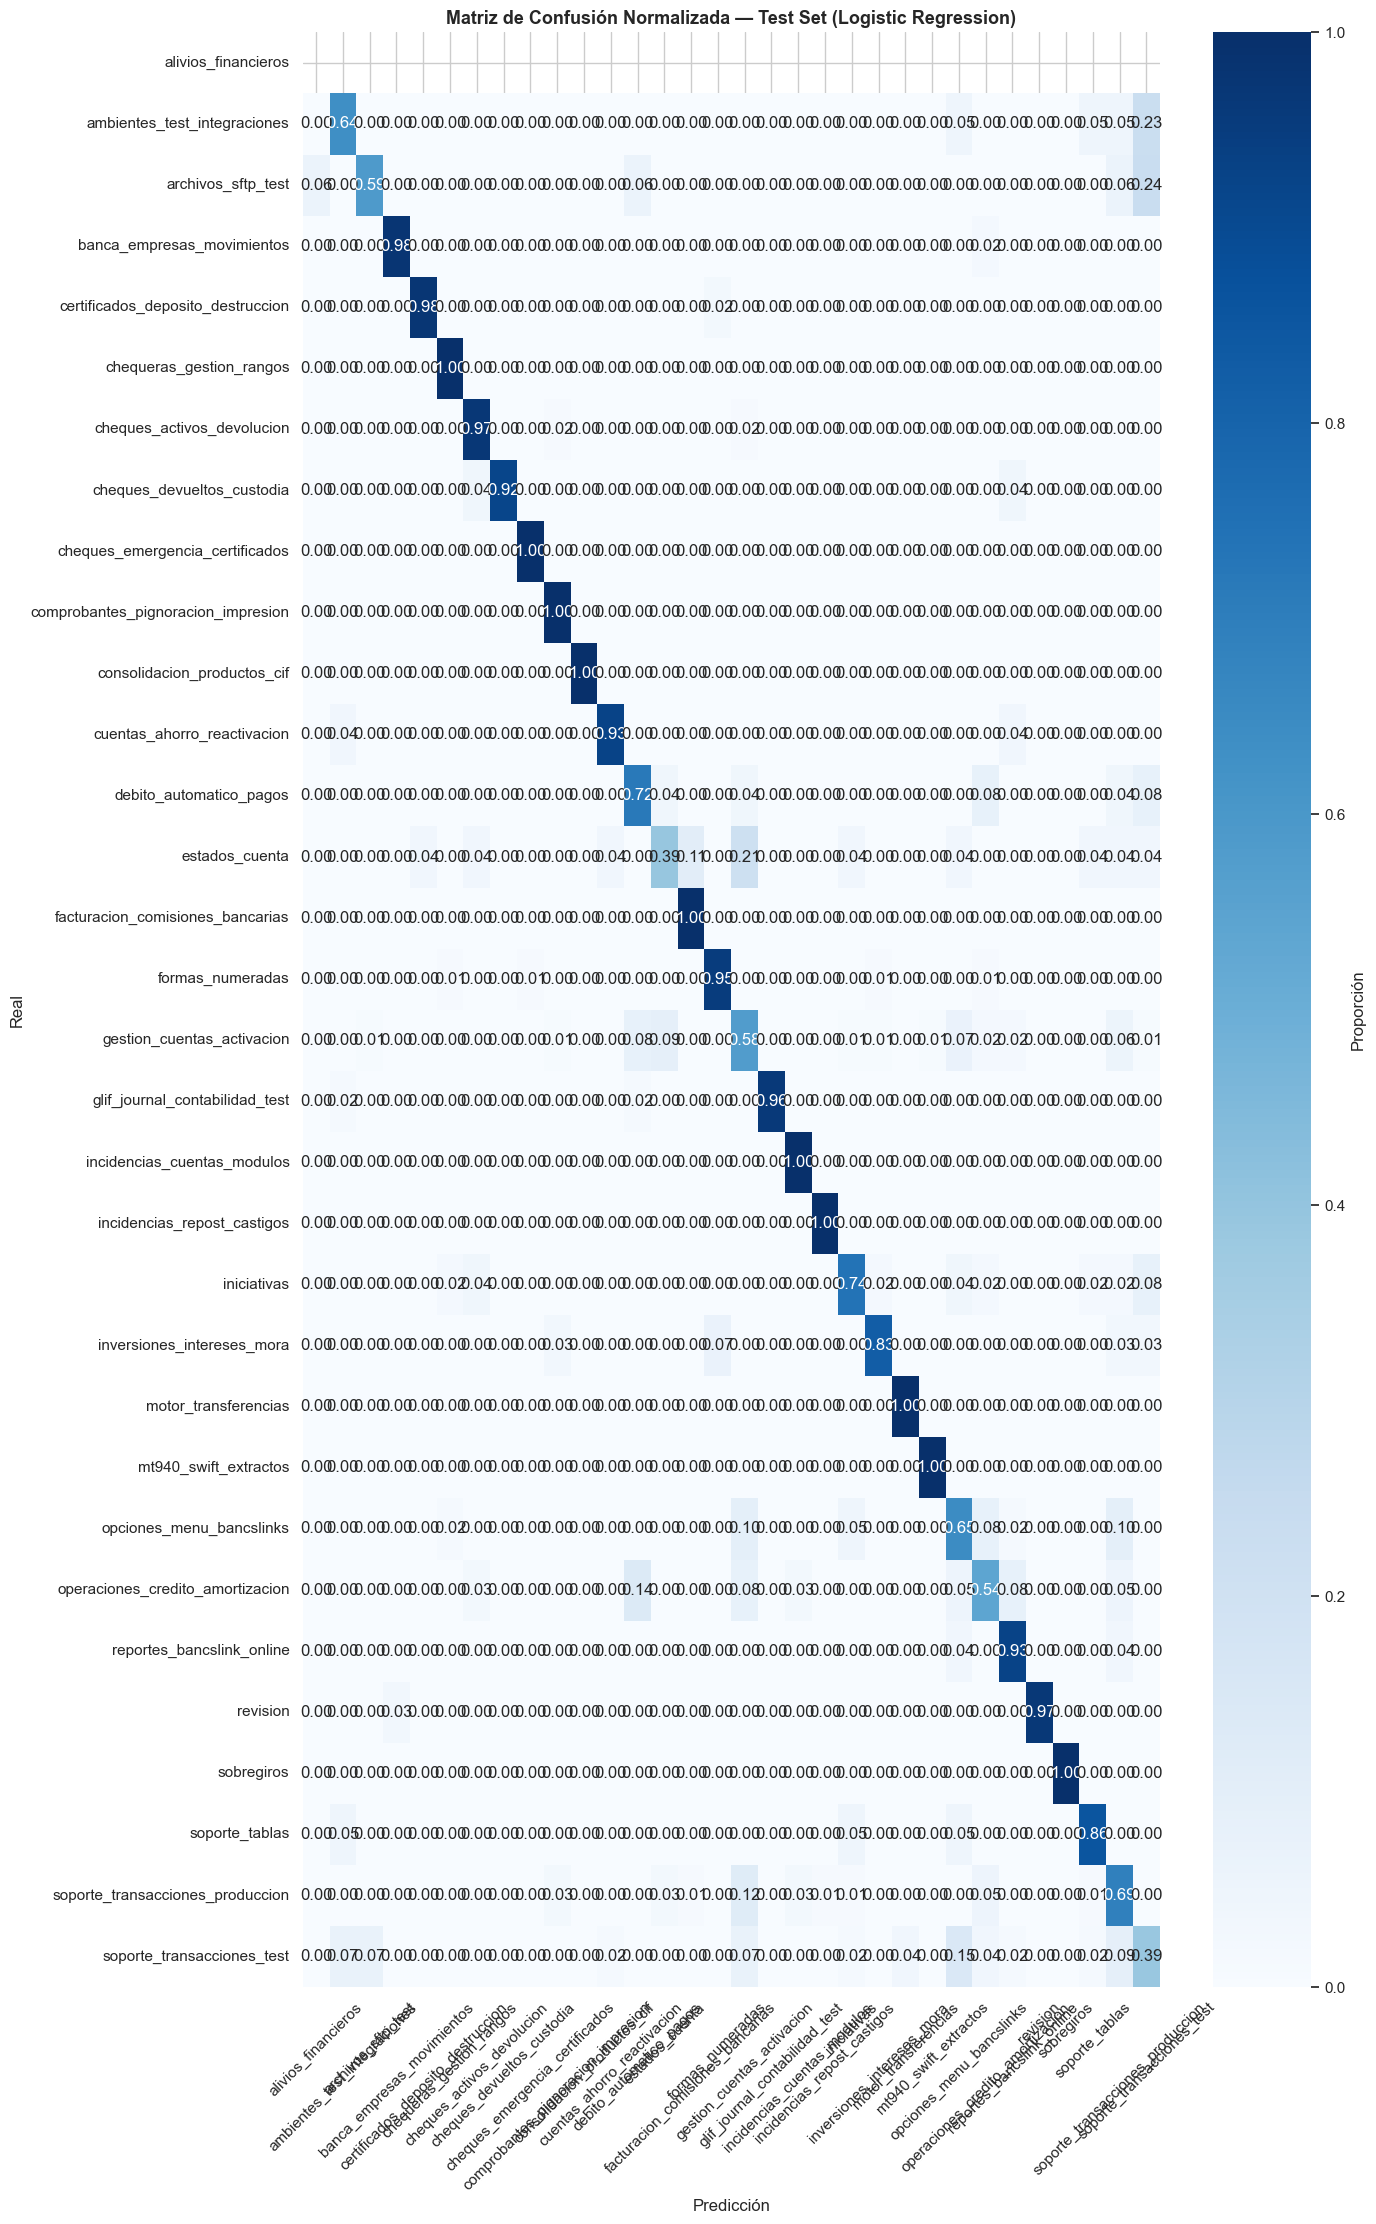

In [200]:
labels_test = sorted(set(list(y_test) + list(y_pred_test)))
cm_test = confusion_matrix(y_test, y_pred_test, labels=labels_test)
cm_test_norm = cm_test.astype('float') / cm_test.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(14, max(8, len(labels_test) * 0.7)))
sns.heatmap(cm_test_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=labels_test, yticklabels=labels_test, ax=ax,
            cbar_kws={'label': 'Proporción'})
ax.set_title(f'Matriz de Confusión Normalizada — Test Set ({mejor})', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicción')
ax.set_ylabel('Real')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### 11.3 Confianza de predicciones

Tipo de confianza: probabilidad calibrada
Umbral de revisión: 0.4
Predicciones con baja confianza: 377 (31.0%)


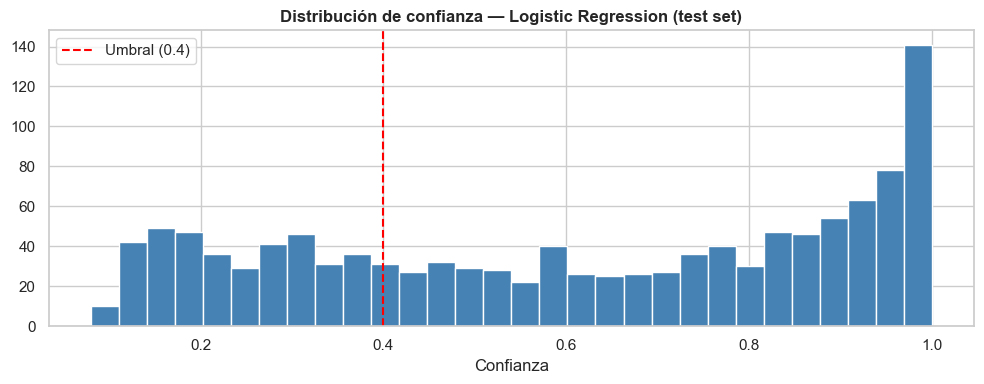

In [201]:
if hasattr(mejor_modelo, 'predict_proba'):
    proba = mejor_modelo.predict_proba(X_test_tfidf)
    confianza = proba.max(axis=1)
    umbral = 0.40
    tipo = 'probabilidad calibrada'
else:
    scores = mejor_modelo.decision_function(X_test_tfidf)
    exp_s = np.exp(scores - scores.max(axis=1, keepdims=True))
    proba = exp_s / exp_s.sum(axis=1, keepdims=True)
    confianza = proba.max(axis=1)
    umbral = 0.10
    tipo = 'softmax(decision_function)'

baja_confianza = (confianza < umbral).sum()
print(f'Tipo de confianza: {tipo}')
print(f'Umbral de revisión: {umbral}')
print(f'Predicciones con baja confianza: {baja_confianza} ({baja_confianza/len(confianza):.1%})')

plt.figure(figsize=(10, 4))
plt.hist(confianza, bins=30, color='steelblue', edgecolor='white')
plt.axvline(umbral, color='red', linestyle='--', label=f'Umbral ({umbral})')
plt.title(f'Distribución de confianza — {mejor} (test set)', fontweight='bold')
plt.xlabel('Confianza')
plt.legend()
plt.tight_layout()
plt.show()

## 12. Persistencia del Modelo

In [202]:
from datetime import date
nombre_modelo = mejor.replace(' ', '_')
hoy = date.today().strftime('%Y%m%d')

carpeta_modelo = os.path.join(os.path.dirname(os.getcwd()), 'Modelos')
os.makedirs(carpeta_modelo, exist_ok=True)

ruta_modelo     = os.path.join(carpeta_modelo, f'modelo_req_{nombre_modelo}_{hoy}.joblib')
ruta_vectorizer = os.path.join(carpeta_modelo, f'vectorizer_req_tfidf_{hoy}.joblib')

joblib.dump(mejor_modelo, ruta_modelo)
joblib.dump(vectorizer,   ruta_vectorizer)

print(f'Modelo guardado:     {ruta_modelo}')
print(f'Vectorizer guardado: {ruta_vectorizer}')
print()
print('Para usar en inferencia futura:')
print(f'  modelo     = joblib.load("{ruta_modelo}")')
print(f'  vectorizer = joblib.load("{ruta_vectorizer}")')
print(f'  X_nuevo    = vectorizer.transform(textos_limpios)')
print(f'  pred       = modelo.predict(X_nuevo)')

Modelo guardado:     c:\ASIGNADOR\Asignador\Modelos\modelo_req_Logistic_Regression_20260615.joblib
Vectorizer guardado: c:\ASIGNADOR\Asignador\Modelos\vectorizer_req_tfidf_20260615.joblib

Para usar en inferencia futura:
  modelo     = joblib.load("c:\ASIGNADOR\Asignador\Modelos\modelo_req_Logistic_Regression_20260615.joblib")
  vectorizer = joblib.load("c:\ASIGNADOR\Asignador\Modelos\vectorizer_req_tfidf_20260615.joblib")
  X_nuevo    = vectorizer.transform(textos_limpios)
  pred       = modelo.predict(X_nuevo)


## 13. Exportar Resultados

In [203]:
# Reconstruir DataFrame de test con predicciones
idx_all = np.arange(len(df))

# Rehacer splits con los mismos índices para mapear de vuelta
if len(X_1ej) > 0:
    mask_1ej_df = pd.Series(df['clasificacion']).isin(clases_1ej).values
    idx_rest = idx_all[~mask_1ej_df]
else:
    idx_rest = idx_all

idx_tv, idx_test_final = train_test_split(
    idx_rest, test_size=0.15, random_state=42, stratify=df['clasificacion'].values[idx_rest]
)
idx_train_final, idx_val_final = train_test_split(
    idx_tv, test_size=0.176, random_state=42, stratify=df['clasificacion'].values[idx_tv]
)

df_test_export = df.iloc[idx_test_final].copy()
df_test_export['clasificacion_predicha'] = y_pred_test
df_test_export['confianza'] = np.round(confianza, 4)
df_test_export['requiere_revision'] = confianza < umbral
df_test_export['modelo_usado'] = mejor
df_test_export['fuente'] = 'test_set'

ruta_export = os.path.join(
    os.path.dirname(os.getcwd()), 'Data',
    f'requerimientos_supervisado_{nombre_modelo}_{hoy}.csv'
)
df_test_export.to_csv(ruta_export, index=False, encoding='utf-8-sig')
print(f'Exportado: {ruta_export}')
print(f'Total tickets en test: {len(df_test_export)}')
df_test_export[['number', 'clasificacion', 'clasificacion_predicha', 'confianza', 'requiere_revision']].head(10)

Exportado: c:\ASIGNADOR\Asignador\Data\requerimientos_supervisado_Logistic_Regression_20260615.csv
Total tickets en test: 1215


,number,clasificacion,clasificacion_predicha,confianza,requiere_revision
1458,RITM0769186,archivos_sftp_test,archivos_sftp_test,0.7253,False
2861,RITM0165887,cheques_devueltos_custodia,cheques_devueltos_custodia,0.7648,False
6347,RITM0788615,cheques_devueltos_custodia,cheques_devueltos_custodia,0.9017,False
1401,RITM0433681,incidencias_cuentas_modulos,incidencias_cuentas_modulos,0.7314,False
5516,RITM0835763,cheques_activos_devolucion,cheques_activos_devolucion,0.5027,False
7741,RITM0060743,soporte_transacciones_test,soporte_transacciones_test,0.1954,True
5692,RITM0606738,cheques_activos_devolucion,cheques_activos_devolucion,0.5761,False
6179,RITM0118724,soporte_transacciones_test,gestion_cuentas_activacion,0.2733,True
6057,RITM0167258,cheques_activos_devolucion,cheques_activos_devolucion,0.7723,False
1333,RITM0885889,comprobantes_pignoracion_impresion,comprobantes_pignoracion_impresion,0.4144,False
